1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean and standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


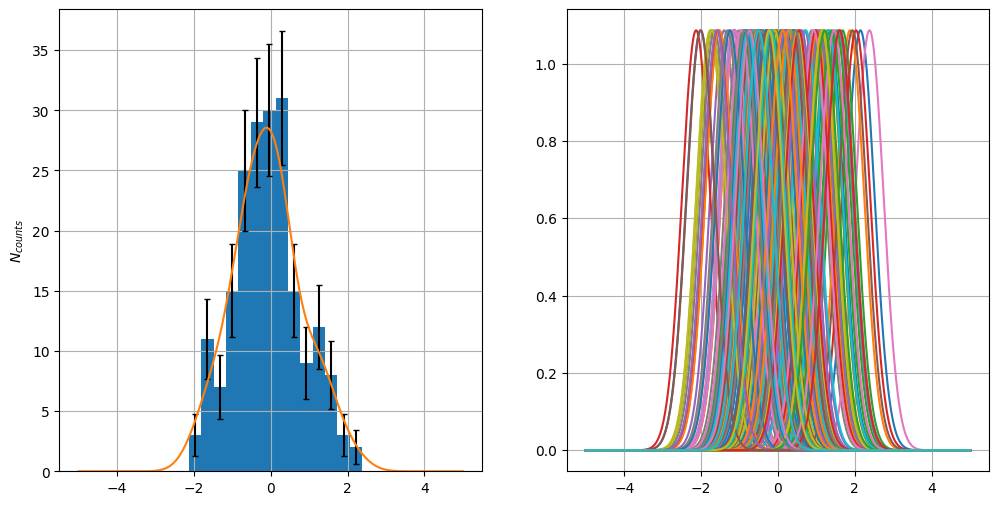

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
from scipy.integrate import trapezoid
N = 200
mean1 = 0
std1 = 1

def func(x, pos):
    if not (x % 1):
        return "%.0f"%x


x = np.random.normal(mean1,std1,N)
nbins = int(np.sqrt(N))
counts, bins = np.histogram(x,nbins)

bincenters = (bins[1:]-bins[:-1])/2+bins[:-1]
devbins = np.sqrt(counts)

fig, (ax1,ax2) = plt.subplots(figsize=(12,6),nrows=1,ncols=2)
ax1.yaxis.set_major_formatter(FuncFormatter(func))

ax1.stairs(counts,bins,fill = True,)
ax1.errorbar(bincenters,counts,devbins,fmt="none",ecolor="k",capsize=2)
ax1.set_ylabel(r"$N_{counts}$")
ax1.grid()

std2 = 1.06*std1*(N)**(-1/5)
xrange = np.linspace(-5*std1,5*std1,500)+np.zeros((N,500))

y = np.array([norm.pdf(xrange[0], j ,std2) for j in x]) #array with the values for the gaussian functions sampled in the rows
ax2.plot(xrange.T,y.T)
ax2.grid()


sumgauss = np.sum(y,axis=0)
normgauss = sumgauss*N*(bins[1:]-bins[:-1])[0]/trapezoid(sumgauss,xrange[0])

ax1.plot(xrange[0],normgauss);



2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

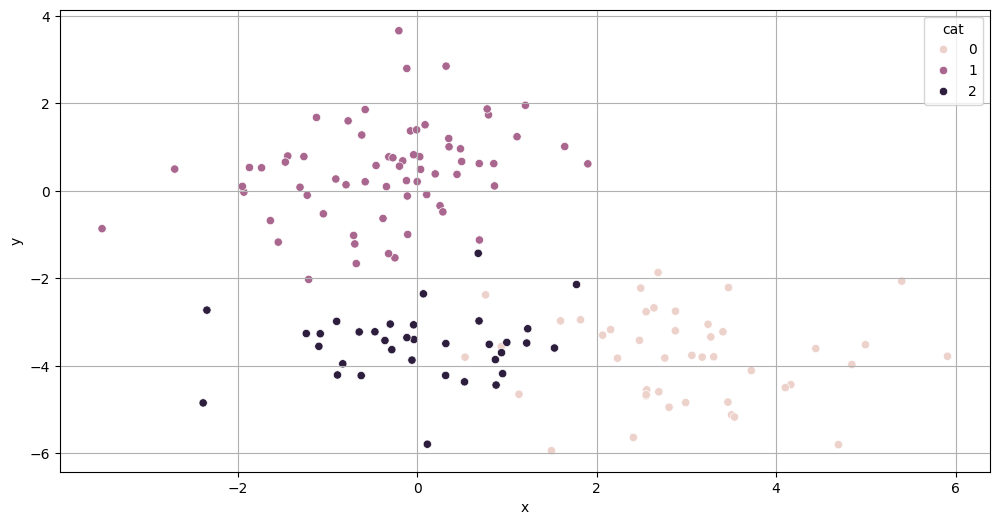

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal 


def dataset_generator(ncat=2):
    cols = ["cat","x","y"]
    all_data= []
    sizes = (100*np.random.rand(ncat)+10).astype(int)
    for i in range(ncat):
        mean = (np.random.rand()*10-5,np.random.rand()*10-5)
        std = np.array([np.random.rand()*5,np.random.rand()*5,np.random.rand()*5,np.random.rand()*5]).resize((2,2))
        vals = multivariate_normal.rvs(mean,std,sizes[i])
        dataf = pd.DataFrame(vals,columns=cols[1:])
        dataf[cols[0]]=i
        all_data.append(dataf)
    return(pd.concat(all_data,ignore_index=True))

dataset = dataset_generator(3)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (12,6))


sns.scatterplot(data = dataset, x = "x" , y = "y", hue = "cat", ax= ax)
plt.grid()


"wget" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


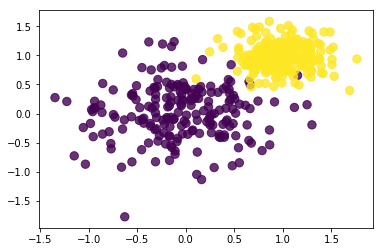

In [3]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

c:\Users\lcdit\OneDrive\Desktop\Uni\Magistrale\Laboratory of Computational Physics\LaboratoryOfComputationalPhysics_Y8\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


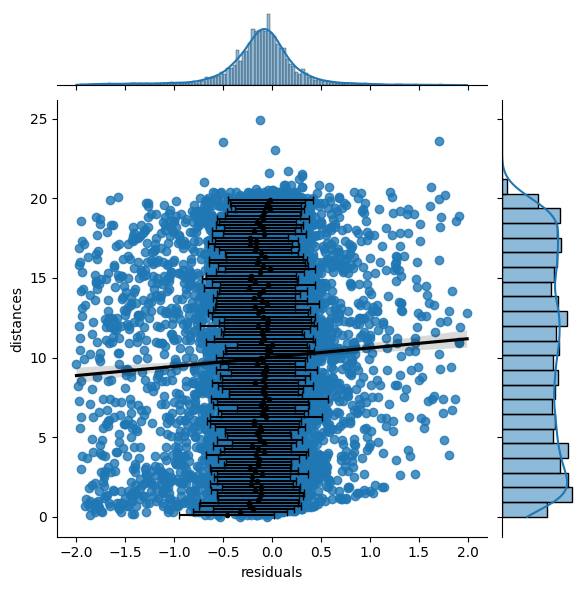

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt


ds = np.load("residuals_261.npy",allow_pickle=True);
data = pd.DataFrame(ds.item())
data = data[data["residuals"].abs()<2]

results = linregress(data["residuals"],data["distances"])

g = sns.jointplot(data, x = "residuals", y = "distances",kind = "reg",joint_kws={'line_kws':{'color':'black'}})

counts, binedges = np.histogram(data["distances"],int(np.sqrt(len(data[data["distances"]<20]))),(0,20))
x = (binedges[1:]-binedges[:-1])/2+binedges[:-1]
y = np.array([data[(data["distances"]<binedges[i+1])&(data["distances"]>binedges[i])]["residuals"].mean() for i in range(len(binedges)-1)])
z = np.array([data[(data["distances"]<binedges[i+1])&(data["distances"]>binedges[i])]["residuals"].std() for i in range(len(binedges)-1)])

g.ax_joint.errorbar(y,x,xerr=z,fmt = "k.",ecolor = "k",linestyle = None,capsize=3)
plt.show()